# Native Backend Benchmark — Iceberg Dimension Tables (No Fugue)

Benchmark SELECT query performance using each engine's **native API** (no Fugue)
across Pandas, DuckDB, Spark, Dask, and Ray on 4 benchmark tables.

Compare with `benchmark_fugue_backends.ipynb` to see Fugue's overhead.

## Prerequisites
Run the Airflow DAG `Insert_Benchmark_Data_To_Iceberg` first to populate the `benchmark` namespace.

## 1. Connect to Iceberg & Load Tables

In [1]:
import time
import pandas as pd
from pyiceberg.catalog import load_catalog

catalog = load_catalog(
    "rest",
    **{
        "uri": "http://iceberg-rest:8181",
        "s3.endpoint": "http://minio:9000",
        "s3.access-key-id": "minioadmin",
        "s3.secret-access-key": "minioadmin",
        "s3.region": "us-east-1",
    }
)

TABLE_NAMES = [
    "small_dim_100k",  # 20 cols, 100K rows
    "large_dim_100k",  # 200 cols, 100K rows
    "small_dim_200k",  # 20 cols, 200K rows
    "large_dim_200k",  # 200 cols, 200K rows
]

# Load all tables as Pandas DataFrames via PyIceberg -> Arrow -> Pandas
tables = {}
for name in TABLE_NAMES:
    fqn = f"benchmark.{name}"
    _start = time.time()
    tables[name] = catalog.load_table(fqn).scan().to_pandas()
    elapsed = time.time() - _start
    rows, cols = tables[name].shape
    print(f"{name}: {rows:,} rows x {cols} cols (loaded in {elapsed:.2f}s)")

small_dim_100k: 100,000 rows x 10 cols (loaded in 0.98s)
large_dim_100k: 100,000 rows x 50 cols (loaded in 1.24s)
small_dim_200k: 200,000 rows x 10 cols (loaded in 0.41s)
large_dim_200k: 200,000 rows x 50 cols (loaded in 2.12s)


## 3. Define Native Engine Benchmarks

Each function takes a Pandas DataFrame, runs a SELECT * equivalent using the engine's native API,
materializes the result back to Pandas, and returns elapsed time.

## 2. Configuration

In [2]:
# Set to False to skip Dask/Ray (useful when running in memory-constrained environments)
INCLUDE_DASK = False
INCLUDE_RAY = False

for name, enabled in [("Dask", INCLUDE_DASK), ("Ray", INCLUDE_RAY)]:
    print(f"{name} backend: {'ENABLED' if enabled else 'DISABLED (skipped during benchmark)'}")

Dask backend: DISABLED (skipped during benchmark)
Ray backend: DISABLED (skipped during benchmark)


In [3]:
def bench_pandas(df):
    """Pandas: copy the DataFrame (equivalent to SELECT *)."""
    start = time.time()
    result = df.copy()
    _ = len(result)  # force materialization
    return time.time() - start


def bench_duckdb(df):
    """DuckDB: SQL query over the Pandas DataFrame."""
    import duckdb
    start = time.time()
    result = duckdb.sql("SELECT * FROM df").fetchdf()
    _ = len(result)
    return time.time() - start


# Pre-create SparkSession once (JVM startup is expensive)
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("NativeBenchmark") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")


def bench_spark(df):
    """Spark: create DataFrame from Pandas, run SQL, collect back."""
    start = time.time()
    sdf = spark.createDataFrame(df)
    sdf.createOrReplaceTempView("data")
    result = spark.sql("SELECT * FROM data").toPandas()
    _ = len(result)
    return time.time() - start


def bench_dask(df):
    """Dask: convert to Dask DataFrame, compute back to Pandas."""
    import dask.dataframe as dd
    start = time.time()
    ddf = dd.from_pandas(df, npartitions=max(1, len(df) // 100_000))
    result = ddf.compute()
    _ = len(result)
    return time.time() - start


def bench_ray(df):
    """Ray: put DataFrame into object store, retrieve it back."""
    import ray
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True)
    start = time.time()
    ref = ray.put(df)
    result = ray.get(ref)
    _ = len(result)
    return time.time() - start


ENGINE_FUNCS = {
    "Pandas": bench_pandas,
    "DuckDB": bench_duckdb,
    "Spark": bench_spark,
}
if INCLUDE_DASK:
    ENGINE_FUNCS["Dask"] = bench_dask
if INCLUDE_RAY:
    ENGINE_FUNCS["Ray"] = bench_ray

ENGINE_LABELS = list(ENGINE_FUNCS.keys())

print(f"Engines ready: {ENGINE_LABELS}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/07 02:03:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Engines ready: ['Pandas', 'DuckDB', 'Spark']


## 4. Run Benchmark

In [4]:
RAY_MAX_RETRIES = 3

results = []

for table_name in TABLE_NAMES:
    df = tables[table_name]
    rows, cols = df.shape
    print(f"\n--- {table_name} ({rows:,} rows x {cols} cols) ---")

    for label, func in ENGINE_FUNCS.items():
        elapsed = None

        if label == "Ray":
            for attempt in range(1, RAY_MAX_RETRIES + 1):
                try:
                    elapsed = func(df)
                    print(f"  {label:>8s}: {elapsed:.3f}s")
                    break
                except Exception:
                    if attempt < RAY_MAX_RETRIES:
                        print(f"  {label:>8s}: attempt {attempt}/{RAY_MAX_RETRIES} failed, retrying...")
                    else:
                        print(f"  {label:>8s}: Insufficient memory error")
        else:
            try:
                elapsed = func(df)
                print(f"  {label:>8s}: {elapsed:.3f}s")
            except Exception as e:
                print(f"  {label:>8s}: FAILED ({e.__class__.__name__}: {e})")

        results.append({
            "table": table_name,
            "rows": rows,
            "cols": cols,
            "engine": label,
            "time_s": elapsed,
        })

bench_df = pd.DataFrame(results)
print("\nBenchmark complete.")


--- small_dim_100k (100,000 rows x 10 cols) ---
    Pandas: 0.174s
    DuckDB: 0.895s


/opt/conda/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:485: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if should_localize and is_datetime64tz_dtype(s.dtype) and s.dt.tz is not None:


     Spark: 10.823s

--- large_dim_100k (100,000 rows x 50 cols) ---
    Pandas: 0.748s
    DuckDB: 5.517s


/opt/conda/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:485: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if should_localize and is_datetime64tz_dtype(s.dtype) and s.dt.tz is not None:
26/07/07 02:03:55 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/07/07 02:03:55 WARN TaskSetManager: Stage 1 contains a task of very large size (3267 KiB). The maximum recommended task size is 1000 KiB.


     Spark: 31.000s

--- small_dim_200k (200,000 rows x 10 cols) ---
    Pandas: 0.139s
    DuckDB: 0.333s


/opt/conda/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:485: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if should_localize and is_datetime64tz_dtype(s.dtype) and s.dt.tz is not None:
26/07/07 02:04:16 WARN TaskSetManager: Stage 2 contains a task of very large size (1047 KiB). The maximum recommended task size is 1000 KiB.


     Spark: 9.479s

--- large_dim_200k (200,000 rows x 50 cols) ---
    Pandas: 1.208s
    DuckDB: 2.642s


/opt/conda/lib/python3.11/site-packages/pyspark/sql/pandas/conversion.py:485: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if should_localize and is_datetime64tz_dtype(s.dtype) and s.dt.tz is not None:
26/07/07 02:04:57 WARN TaskSetManager: Stage 3 contains a task of very large size (6575 KiB). The maximum recommended task size is 1000 KiB.


     Spark: 73.623s

Benchmark complete.


## 5. Results Table

In [5]:
# Pivot: rows = table, columns = engine, values = time
pivot = bench_df.pivot(index="table", columns="engine", values="time_s")
pivot = pivot[ENGINE_LABELS]  # consistent column order
pivot = pivot.loc[TABLE_NAMES]  # consistent row order
pivot.columns.name = None
pivot.index.name = "Table"

# Add row/col metadata
meta = bench_df.drop_duplicates("table").set_index("table")[["rows", "cols"]]
display_df = meta.join(pivot)
display_df

,rows,cols,Pandas,DuckDB,Spark
table,,,,,
small_dim_100k,100000,10,0.173648,0.894731,10.823113
large_dim_100k,100000,50,0.747893,5.517243,30.999739
small_dim_200k,200000,10,0.138730,0.333388,9.478811
large_dim_200k,200000,50,1.207697,2.641596,73.622799


## 6. Visualization — Grouped Bar Chart

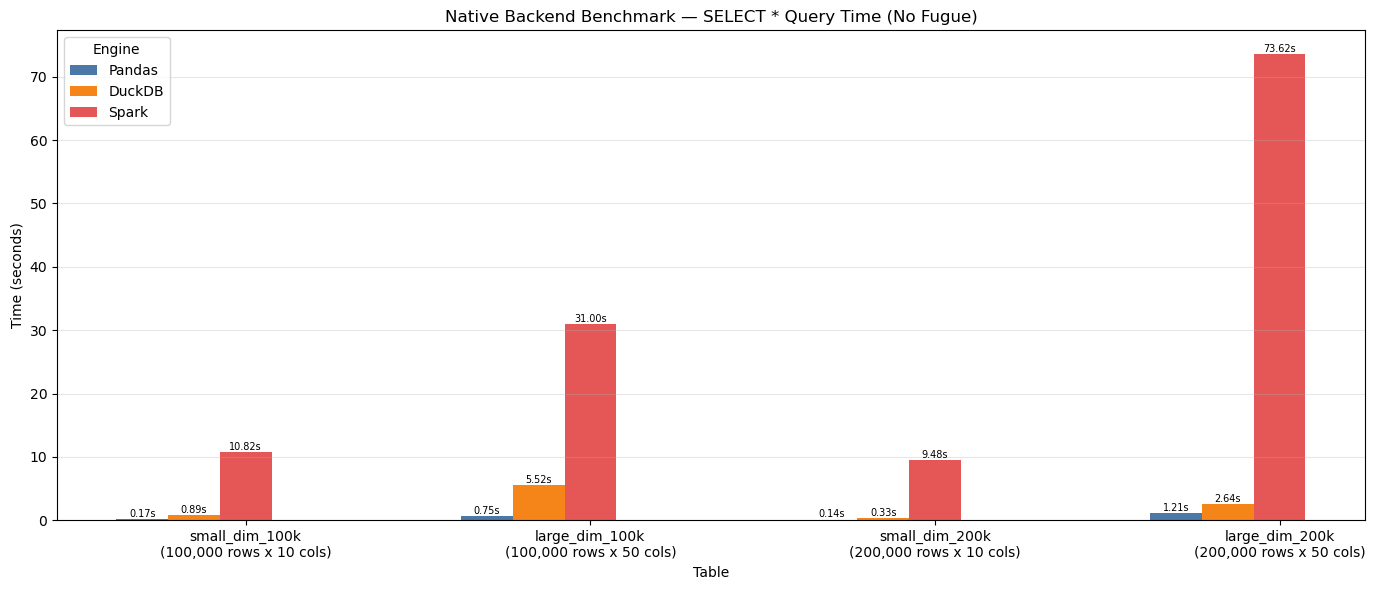

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(TABLE_NAMES))
width = 0.15
colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B"]

for i, (label, color) in enumerate(zip(ENGINE_LABELS, colors)):
    times = [pivot.loc[t, label] if pd.notna(pivot.loc[t, label]) else 0 for t in TABLE_NAMES]
    bars = ax.bar(x + i * width, times, width, label=label, color=color)
    for bar, val in zip(bars, times):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{val:.2f}s", ha="center", va="bottom", fontsize=7)

ax.set_xlabel("Table")
ax.set_ylabel("Time (seconds)")
ax.set_title("Native Backend Benchmark — SELECT * Query Time (No Fugue)")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"{t}\n({tables[t].shape[0]:,} rows x {tables[t].shape[1]} cols)" for t in TABLE_NAMES])
ax.legend(title="Engine")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Fastest Engine Per Table

In [7]:
summary = []
for table_name in TABLE_NAMES:
    row = pivot.loc[table_name].dropna()
    if len(row) > 0:
        fastest_engine = row.idxmin()
        fastest_time = row.min()
        slowest_engine = row.idxmax()
        slowest_time = row.max()
        summary.append({
            "Table": table_name,
            "Rows": f"{tables[table_name].shape[0]:,}",
            "Cols": tables[table_name].shape[1],
            "Fastest": f"{fastest_engine} ({fastest_time:.3f}s)",
            "Slowest": f"{slowest_engine} ({slowest_time:.3f}s)",
            "Speedup": f"{slowest_time / fastest_time:.1f}x",
        })

pd.DataFrame(summary).set_index("Table")

,Rows,Cols,Fastest,Slowest,Speedup
Table,,,,,
small_dim_100k,"100,000",10,Pandas (0.174s),Spark (10.823s),62.3x
large_dim_100k,"100,000",50,Pandas (0.748s),Spark (31.000s),41.4x
small_dim_200k,"200,000",10,Pandas (0.139s),Spark (9.479s),68.3x
large_dim_200k,"200,000",50,Pandas (1.208s),Spark (73.623s),61.0x


## 8. Cleanup

In [8]:
spark.stop()
print("SparkSession stopped.")

SparkSession stopped.
